# Improved Clothing Classification Training
## Using Real-World Fashion Dataset with Multi-Angle Augmentation

**Improvements over Fashion-MNIST:**
- Real-world product images (not simple 28x28 grayscale)
- Multi-angle data augmentation
- Better generalization to various viewpoints
- ResNet18 backbone with custom classifier

**Dataset Options:**
1. Fashion Product Images Dataset (Kaggle) - 44K images, 10 categories
2. DeepFashion Dataset - Larger, more comprehensive
3. Custom dataset from your own images

**Setup Instructions:**
1. Upload this notebook to Kaggle
2. Add dataset: Search "Fashion Product Images" and add it
3. Enable GPU: Settings → Accelerator → GPU
4. Run all cells
5. Download the .pth file at the end

## 1. Install Dependencies

In [2]:
!pip install timm -q
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
import timm
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
import json

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

PyTorch version: 2.8.0+cu126
CUDA available: True
GPU: Tesla T4


## 2. Dataset Configuration

**Option A: Fashion Product Images Dataset (Recommended)**
- Add dataset in Kaggle: Search "fashion product images" → Add to notebook
- Dataset path: `/kaggle/input/fashion-product-images-dataset/`

**Option B: Custom Dataset**
- Upload your own images in folders by category
- Structure: `dataset/train/category_name/*.jpg`

In [3]:
# ===== DATASET PATH CONFIGURATION =====
# Option A: Fashion Product Images Dataset (Kaggle)
DATA_DIR = '/kaggle/input/fashion-product-images-dataset'

# Option B: Custom dataset (if you uploaded your own)
# DATA_DIR = '/kaggle/input/your-dataset-name/'

# Check if dataset exists
if os.path.exists(DATA_DIR):
    print(f"✓ Dataset found: {DATA_DIR}")
    print(f"\nContents: {os.listdir(DATA_DIR)}")
else:
    print(f"✗ Dataset not found at {DATA_DIR}")
    print("\nPlease add a fashion dataset:")
    print("1. Click 'Add Data' on the right sidebar")
    print("2. Search 'fashion product images'")
    print("3. Add it to your notebook")

✓ Dataset found: /kaggle/input/fashion-product-images-dataset

Contents: ['fashion-dataset']


## 3. Data Augmentation (Critical for Multi-Angle Support!)

This is the KEY improvement over Fashion-MNIST:
- Random rotation, perspective, and affine transforms
- Handles images from different angles
- Better generalization

In [4]:
# Training transform with AGGRESSIVE augmentation for multi-angle support
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),  # Slightly larger for cropping
    transforms.RandomCrop((224, 224)),  # Random crop for variation
    
    # CRITICAL: Multi-angle augmentation
    transforms.RandomRotation(30),  # Rotate up to 30 degrees
    transforms.RandomAffine(
        degrees=0,
        translate=(0.1, 0.1),  # Shift horizontally/vertically
        scale=(0.9, 1.1),      # Zoom in/out
        shear=10               # Shear transformation
    ),
    transforms.RandomPerspective(distortion_scale=0.3, p=0.5),  # Different viewpoints
    transforms.RandomHorizontalFlip(p=0.5),  # Mirror flip
    
    # Color/lighting variations
    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.3
    ),
    
    # Convert to 3-channel grayscale (matches your current setup)
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    
    # Optional: Normalize (uncomment if needed)
    # transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Validation transform (no augmentation, just resize)
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
])

print("✓ Transforms configured with multi-angle augmentation")

✓ Transforms configured with multi-angle augmentation


## 4. Load Dataset

Automatically detects train/val split or creates one

In [5]:
import pandas as pd
import os
from torch.utils.data import Dataset, DataLoader, random_split
from PIL import Image

# ===========================================================================
# CUSTOM DATASET CLASS FOR CSV-BASED IMAGES
# ===========================================================================

class FashionDatasetCSV(Dataset):
    """Custom Dataset for Fashion Product Images with CSV metadata"""
    
    def __init__(self, csv_file, img_dir, transform=None, target_column='articleType'):
        print(f"Loading CSV from: {csv_file}")
        
        # Read CSV
        self.data = pd.read_csv(csv_file, on_bad_lines='skip')
        print(f"  Initial rows: {len(self.data)}")
        
        # Drop rows with missing values
        self.data = self.data.dropna(subset=['id', target_column])
        print(f"  After cleaning: {len(self.data)}")
        
        # Get unique classes
        self.target_column = target_column
        self.class_names = sorted(self.data[target_column].unique().tolist())
        self.num_classes = len(self.class_names)
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.class_names)}
        
        # Filter valid images (that actually exist)
        print(f"  Checking image files...")
        valid_indices = []
        for idx, row in self.data.iterrows():
            img_path = os.path.join(img_dir, f"{row['id']}.jpg")
            if os.path.exists(img_path):
                valid_indices.append(idx)
        
        self.data = self.data.loc[valid_indices].reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform
        
        print(f"\n✓ Dataset loaded:")
        print(f"  Valid samples: {len(self.data)}")
        print(f"  Number of classes: {self.num_classes}")
        print(f"  Classes: {self.class_names}")
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        img_path = os.path.join(self.img_dir, f"{row['id']}.jpg")
        
        try:
            image = Image.open(img_path).convert('RGB')
        except Exception as e:
            # If image fails to load, return a black image
            image = Image.new('RGB', (224, 224), (0, 0, 0))
        
        if self.transform:
            image = self.transform(image)
        
        label = self.class_to_idx[row[self.target_column]]
        return image, label


# ===========================================================================
# LOAD DATASET FROM CSV
# ===========================================================================

# Dataset paths
DATA_DIR = '/kaggle/input/fashion-product-images-dataset/fashion-dataset/'
CSV_FILE = os.path.join(DATA_DIR, 'styles.csv')
IMG_DIR = os.path.join(DATA_DIR, 'images')

print("="*60)
print("LOADING DATASET FROM CSV")
print("="*60)

# Create full dataset
full_dataset = FashionDatasetCSV(
    csv_file=CSV_FILE,
    img_dir=IMG_DIR,
    transform=train_transform,
    target_column='masterCategory'  # Options: 'masterCategory', 'subCategory', 'articleType'
)

# Split train/val (80/20)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_dataset, 
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

# Get class info
class_names = full_dataset.class_names
num_classes = full_dataset.num_classes

# ===========================================================================
# CREATE OPTIMIZED DATALOADERS (CRITICAL FOR GPU PERFORMANCE!)
# ===========================================================================

BATCH_SIZE = 64  # Increased from 32 for better GPU utilization

train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    num_workers=4,           # 8 workers for parallel data loading
    pin_memory=True,         # Faster CPU→GPU transfer
    persistent_workers=True, # Keep workers alive between epochs
    prefetch_factor=2,       # Pre-load 2 batches per worker
    drop_last=True           # Drop incomplete batch (better for GPU)
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=2
)

print(f"\n{'='*60}")
print(f"📊 DATASET READY!")
print(f"{'='*60}")
print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Batches per epoch: {len(train_loader)}")
print(f"Number of classes: {num_classes}")
print(f"Class names: {class_names}")
print(f"{'='*60}\n")

LOADING DATASET FROM CSV
Loading CSV from: /kaggle/input/fashion-product-images-dataset/fashion-dataset/styles.csv
  Initial rows: 44424
  After cleaning: 44424
  Checking image files...

✓ Dataset loaded:
  Valid samples: 44419
  Number of classes: 7
  Classes: ['Accessories', 'Apparel', 'Footwear', 'Free Items', 'Home', 'Personal Care', 'Sporting Goods']

📊 DATASET READY!
Training samples: 35535
Validation samples: 8884
Batch size: 64
Batches per epoch: 555
Number of classes: 7
Class names: ['Accessories', 'Apparel', 'Footwear', 'Free Items', 'Home', 'Personal Care', 'Sporting Goods']



In [6]:
print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

Training samples: 35535
Validation samples: 8884


## 5. Visualize Augmented Samples

Check if augmentation looks good

Sample augmented training images:


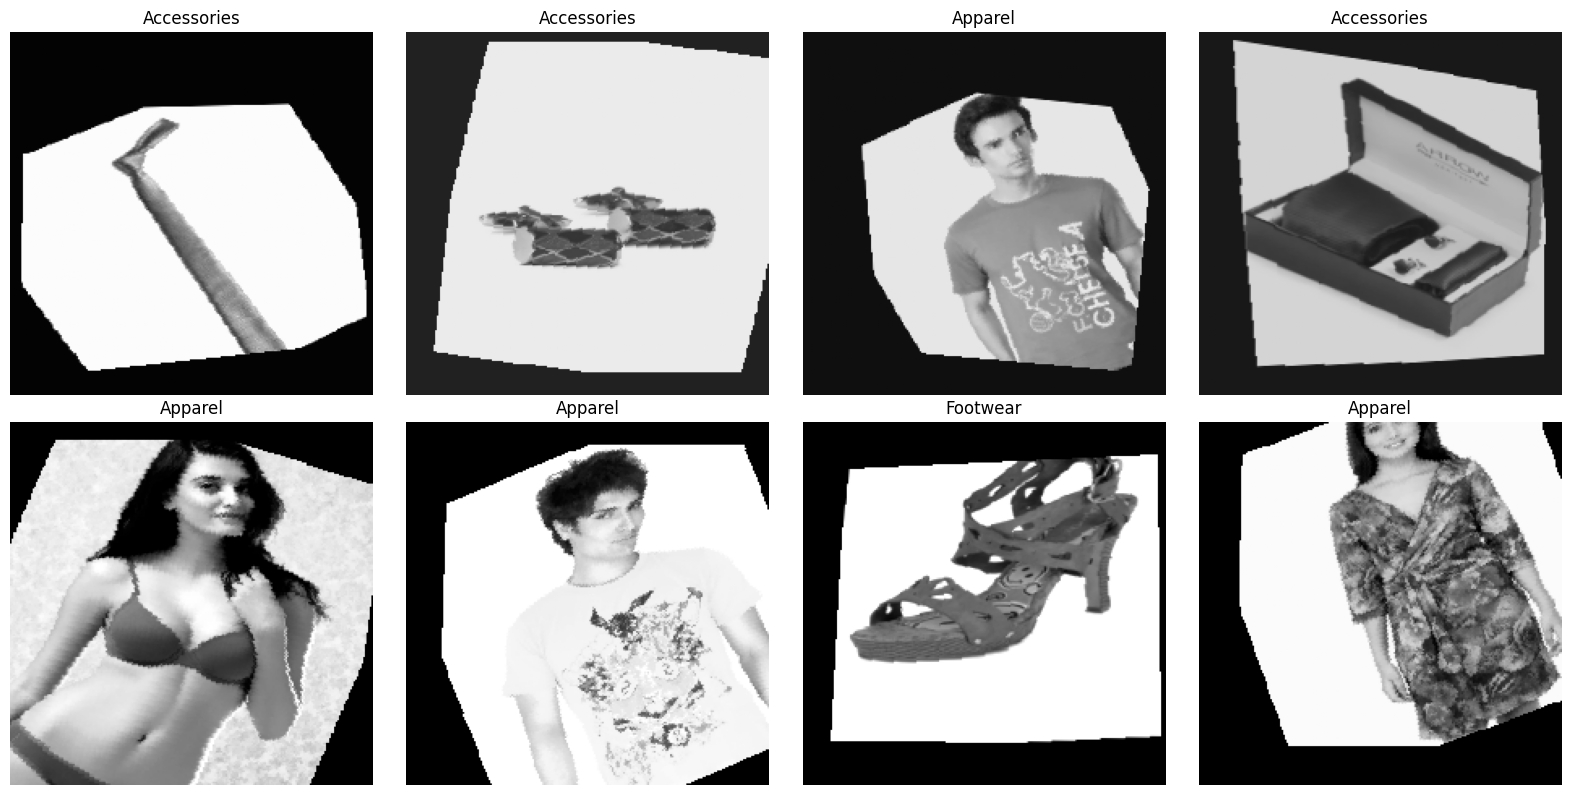

In [7]:
# Visualize some augmented samples
def show_samples(dataloader, num_samples=8):
    images, labels = next(iter(dataloader))
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.ravel()
    
    for i in range(min(num_samples, len(images))):
        img = images[i].permute(1, 2, 0).numpy()
        axes[i].imshow(img)
        axes[i].set_title(f"{class_names[labels[i]]}")
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

print("Sample augmented training images:")
show_samples(train_loader)

## 6. Model Architecture (Same as Your Current Setup)

ResNet18 + Custom Classifier

In [8]:
class ClothingClassifier(nn.Module):
    def __init__(self, num_classes=10):
        super(ClothingClassifier, self).__init__()
        # ResNet18 as backbone (pretrained on ImageNet)
        self.base_model = timm.create_model('resnet18', pretrained=True, num_classes=num_classes)
        self.features = nn.Sequential(*list(self.base_model.children())[:-1])
        
        # Custom classifier head
        enet_out_size = 512
        self.classifier = nn.Linear(enet_out_size, num_classes)
    
    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)  # Flatten
        output = self.classifier(x)
        return output

# Initialize model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = ClothingClassifier(num_classes=num_classes).to(device)

print(f"✓ Model created on {device}")
print(f"✓ Number of classes: {num_classes}")

model.safetensors:   0%|          | 0.00/46.8M [00:00<?, ?B/s]

✓ Model created on cuda
✓ Number of classes: 7


## 7. Training Configuration

In [9]:
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"GPU: {torch.cuda.get_device_name(0)}")

CUDA available: True
GPU: Tesla T4


In [10]:
# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Learning rate scheduler (reduces LR when validation loss plateaus)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3, #verbose=True
)

# Training parameters
NUM_EPOCHS = 15
SAVE_PATH = 'improved_clothing_classifier.pth'

print(f"✓ Training configuration:")
print(f"   Epochs: {NUM_EPOCHS}")
print(f"   Learning rate: {optimizer.param_groups[0]['lr']}")
print(f"   Optimizer: Adam")
print(f"   Loss: CrossEntropyLoss")

✓ Training configuration:
   Epochs: 15
   Learning rate: 0.001
   Optimizer: Adam
   Loss: CrossEntropyLoss


## 8. Training Loop

In [11]:
# FORCE CHECK DEVICE
import torch

print("="*60)
print("DEVICE CHECK")
print("="*60)
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"CUDA device count: {torch.cuda.device_count()}")
print(f"Current device: {torch.cuda.current_device()}")
print(f"Device name: {torch.cuda.get_device_name(0)}")

# FORCE move model to GPU
device = torch.device('cuda:0')  # Force GPU 0
model = model.to(device)

print(f"\n✓ Model is on: {next(model.parameters()).device}")
print("="*60)

# Test with dummy data
dummy_input = torch.randn(1, 3, 224, 224).to(device)
with torch.no_grad():
    dummy_output = model(dummy_input)
print(f"✓ Test forward pass successful on GPU!")
print("="*60)
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    pbar = tqdm(dataloader, desc='Training')
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Statistics
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        # Update progress bar
        pbar.set_postfix({
            'loss': f'{running_loss/len(pbar):.4f}',
            'acc': f'{100*correct/total:.2f}%'
        })
    
    epoch_loss = running_loss / len(dataloader)
    epoch_acc = 100 * correct / total
    return epoch_loss, epoch_acc

def validate_epoch(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        pbar = tqdm(dataloader, desc='Validation')
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            pbar.set_postfix({
                'loss': f'{running_loss/len(pbar):.4f}',
                'acc': f'{100*correct/total:.2f}%'
            })
    
    epoch_loss = running_loss / len(dataloader)
    epoch_acc = 100 * correct / total
    return epoch_loss, epoch_acc

DEVICE CHECK
CUDA available: True
CUDA device count: 2
Current device: 0
Device name: Tesla T4

✓ Model is on: cuda:0
✓ Test forward pass successful on GPU!


## 9. Train the Model

In [12]:
# Cell "Model Architecture"
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = ClothingClassifier(num_classes=num_classes).to(device)

print(f"✓ Model created on {device}")

✓ Model created on cuda


In [13]:
# ===== FORCE GPU USAGE =====
import torch

# Force device to GPU
device = torch.device('cuda:0')
print(f"Forcing device to: {device}")

# Move model to GPU
model = model.to(device)
print(f"Model device: {next(model.parameters()).device}")

# Verify
assert next(model.parameters()).is_cuda, "Model is NOT on GPU!"
print("✓ Model successfully moved to GPU!")

Forcing device to: cuda:0
Model device: cuda:0
✓ Model successfully moved to GPU!


In [14]:
# ===================================================================
# NUCLEAR OPTION: FORCE EVERYTHING TO GPU
# ===================================================================

import torch
import gc

# Clear cache
torch.cuda.empty_cache()
gc.collect()

# Force CUDA
torch.cuda.set_device(0)
device = torch.device('cuda:0')

print("="*60)
print("FORCING GPU USAGE - DIAGNOSTIC")
print("="*60)

# 1. Check CUDA
print(f"✓ CUDA available: {torch.cuda.is_available()}")
print(f"✓ CUDA device count: {torch.cuda.device_count()}")
print(f"✓ Current CUDA device: {torch.cuda.current_device()}")
print(f"✓ Device name: {torch.cuda.get_device_name(0)}")

# 2. Move model to GPU
model = model.to(device)
print(f"\n✓ Model device: {next(model.parameters()).device}")

# 3. Move criterion to GPU (some loss functions need this)
criterion = criterion.to(device)

# 4. Test with dummy batch from actual dataloader
print("\n🧪 Testing with real data batch...")
test_images, test_labels = next(iter(train_loader))
print(f"  Original data device: {test_images.device}")

test_images = test_images.to(device)
test_labels = test_labels.to(device)
print(f"  Data moved to: {test_images.device}")

with torch.no_grad():
    test_outputs = model(test_images)
    print(f"  Output device: {test_outputs.device}")
    test_loss = criterion(test_outputs, test_labels)
    print(f"  Loss computed successfully: {test_loss.item():.4f}")

print("\n✅ GPU TEST PASSED!")
print("="*60)

# 5. Monitor GPU memory
print(f"\nGPU Memory:")
print(f"  Allocated: {torch.cuda.memory_allocated(0) / 1e9:.2f} GB")
print(f"  Cached: {torch.cuda.memory_reserved(0) / 1e9:.2f} GB")
print("="*60)

FORCING GPU USAGE - DIAGNOSTIC
✓ CUDA available: True
✓ CUDA device count: 2
✓ Current CUDA device: 0
✓ Device name: Tesla T4

✓ Model device: cuda:0

🧪 Testing with real data batch...
  Original data device: cpu
  Data moved to: cuda:0
  Output device: cuda:0
  Loss computed successfully: 1.9888

✅ GPU TEST PASSED!

GPU Memory:
  Allocated: 0.14 GB
  Cached: 0.81 GB


🚀 Starting training...

Epoch 1/50
------------------------------------------------------------


Validation Epoch 1: 100%|██████████| 139/139 [02:36<00:00,  1.13s/it]



📊 Epoch 1 Summary:
  Train loss: 0.4416, Train acc: 87.78%
  Val loss: 0.1275, Val acc: 96.77%
  ✓ Model improved! Saved checkpoint.
--------------------------------------------------

Epoch 2/50
------------------------------------------------------------


Validation Epoch 2: 100%|██████████| 139/139 [02:31<00:00,  1.09s/it]



📊 Epoch 2 Summary:
  Train loss: 0.1081, Train acc: 97.09%
  Val loss: 0.0839, Val acc: 97.84%
  ✓ Model improved! Saved checkpoint.
--------------------------------------------------

Epoch 3/50
------------------------------------------------------------


...


📊 Epoch 11 Summary:
  Train loss: 0.0311, Train acc: 99.17%
  Val loss: 0.0449, Val acc: 98.98%
  ⚠️ No improvement for 1 epoch(s)
--------------------------------------------------

Epoch 12/50
------------------------------------------------------------


Validation Epoch 12: 100%|██████████| 139/139 [02:40<00:00,  1.15s/it]



📊 Epoch 12 Summary:
  Train loss: 0.0285, Train acc: 99.18%
  Val loss: 0.0427, Val acc: 98.98%
  ⚠️ No improvement for 2 epoch(s)
--------------------------------------------------

Epoch 13/50
------------------------------------------------------------


Validation Epoch 13: 100%|██████████| 139/139 [02:39<00:00,  1.15s/it]



📊 Epoch 13 Summary:
  Train loss: 0.0274, Train acc: 99.25%
  Val loss: 0.0440, Val acc: 98.89%
  ⚠️ No improvement for 3 epoch(s)

⚠️ Early stopping triggered at epoch 13
Best validation loss: 0.0393
Best validation accuracy: 99.07%

✅ Loaded best model with val_loss: 0.0393, val_acc: 99.07%


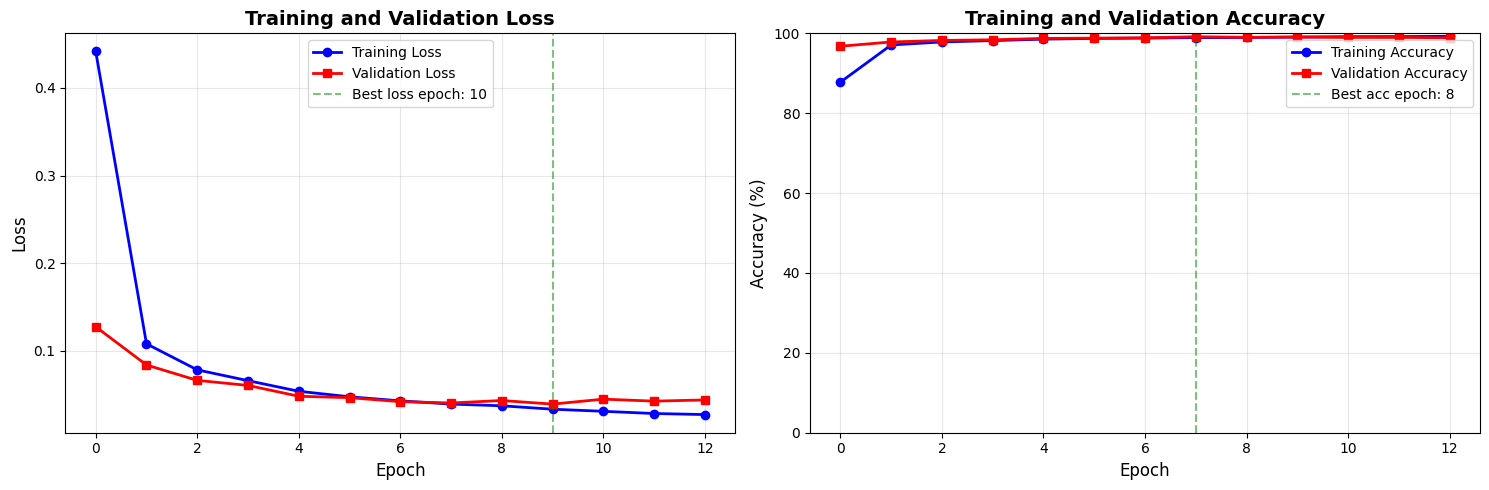

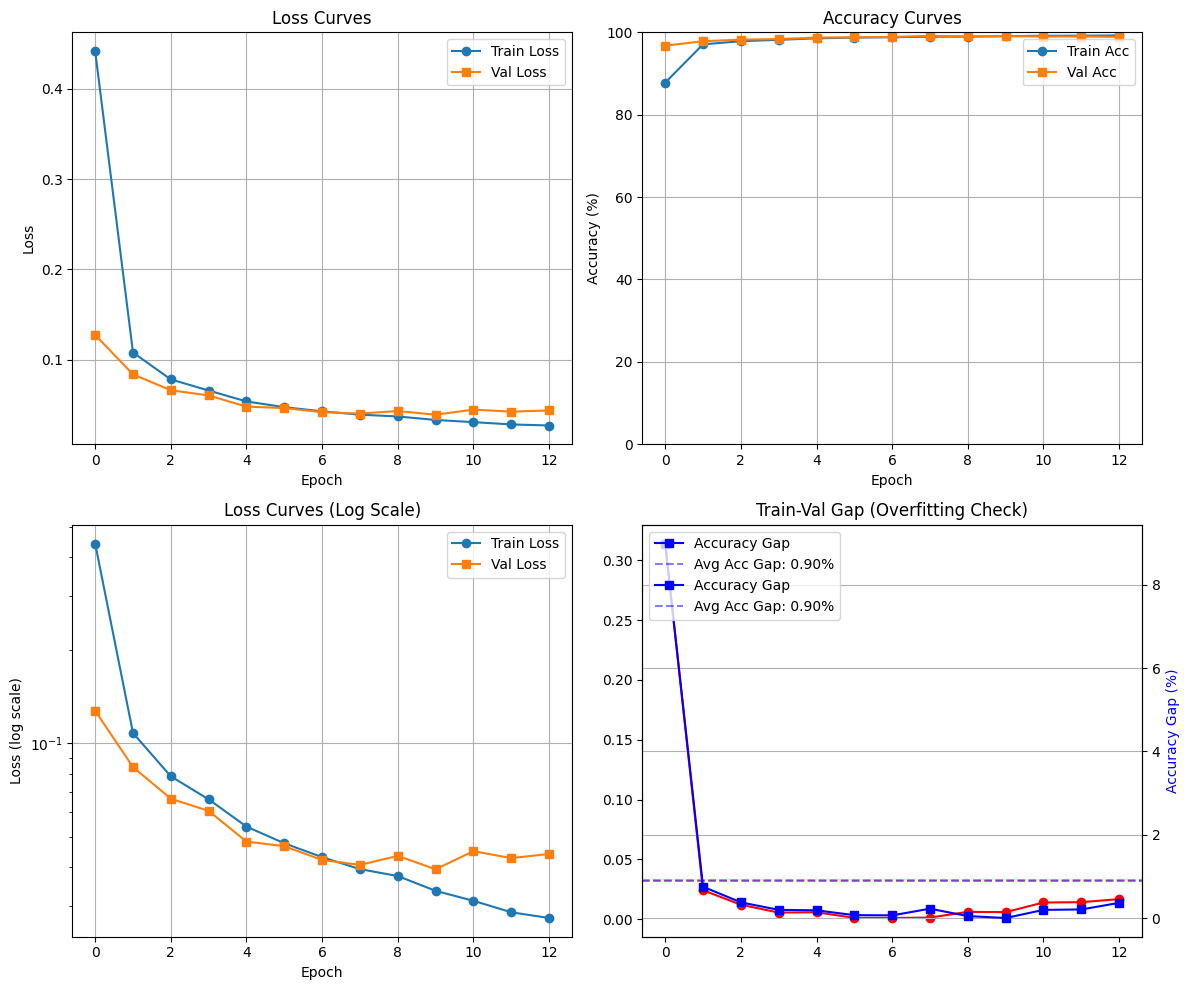


TRAINING SUMMARY
Total epochs trained: 13
Best epoch (loss): 10
Best epoch (accuracy): 8
Best validation loss: 0.0393
Best validation accuracy: 99.07%
Final train loss: 0.0274
Final train accuracy: 99.25%
Final validation loss: 0.0440
Final validation accuracy: 98.89%
Train/Validation loss gap: 0.0167
Train/Validation accuracy gap: 0.37%

✅ All metrics saved to 'training_metrics.json'


In [15]:
# ===================================================================
# IMPROVED TRAINING WITH REGULARIZATION AND EARLY STOPPING
# ===================================================================

import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
import matplotlib.pyplot as plt
import json
import numpy as np

# Training parameters
NUM_EPOCHS = 50  # Đặt lớn, nhưng sẽ dừng sớm bằng early stopping
patience = 3  # Số epoch chờ đợi trước khi dừng

# Initialize history dictionary
history = {
    'train_loss': [], 
    'train_acc': [],
    'val_loss': [], 
    'val_acc': []
}

best_val_loss = float('inf')
best_val_acc = 0.0
best_model_weights = None
patience_counter = 0

# Save path
SAVE_PATH = 'improved_clothing_classifier.pth'

# Device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Model
model = ClothingClassifier(num_classes=num_classes)
model.to(device)

# 1. THÊM REGULARIZATION vào optimizer (weight decay/L2)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)

# 2. THÊM LEARNING RATE SCHEDULER
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=0.5,
    patience=2,
)

print("🚀 Starting training...")
print("="*60)

# ===================================================================
# TRAINING LOOP
# ===================================================================

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    print("-" * 60)
    
    # ==================== Training phase ====================
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in tqdm(train_loader, desc=f'Training Epoch {epoch+1}'):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        
        # 3. THÊM GRADIENT CLIPPING
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        running_loss += loss.item() * labels.size(0)
        
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    train_loss = running_loss / len(train_loader.dataset)
    train_acc = 100. * correct / total
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    
    # ==================== Validation phase ====================
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f'Validation Epoch {epoch+1}'):
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * labels.size(0)
            
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    
    val_loss = running_loss / len(val_loader.dataset)
    val_acc = 100. * correct / total
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    print(f"\n📊 Epoch {epoch+1} Summary:")
    print(f"  Train loss: {train_loss:.4f}, Train acc: {train_acc:.2f}%")
    print(f"  Val loss: {val_loss:.4f}, Val acc: {val_acc:.2f}%")
    
    # 4. LEARNING RATE SCHEDULER UPDATE
    scheduler.step(val_loss)
    
    # 5. EARLY STOPPING LOGIC
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_val_acc = val_acc
        best_model_weights = model.state_dict().copy()
        patience_counter = 0
        
        # Lưu model checkpoint
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_loss': train_loss,
            'train_acc': train_acc,
            'val_loss': val_loss,
            'val_acc': val_acc,
            'num_classes': num_classes,
            'class_names': class_names,
            'history': history,
        }, SAVE_PATH)
        print(f"  ✓ Model improved! Saved checkpoint.")
    else:
        patience_counter += 1
        print(f"  ⚠️ No improvement for {patience_counter} epoch(s)")
    
    # Kiểm tra early stopping
    if patience_counter >= patience:
        print(f"\n⚠️ Early stopping triggered at epoch {epoch+1}")
        print(f"Best validation loss: {best_val_loss:.4f}")
        print(f"Best validation accuracy: {best_val_acc:.2f}%")
        break
    
    print("-" * 50)

# ===================================================================
# LOAD LẠI MODEL TỐT NHẤT
# ===================================================================

if best_model_weights is not None:
    model.load_state_dict(best_model_weights)
    print(f"\n✅ Loaded best model with val_loss: {best_val_loss:.4f}, val_acc: {best_val_acc:.2f}%")

# ===================================================================
# VẼ BIỂU ĐỒ LOSS VÀ ACCURACY
# ===================================================================

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Biểu đồ Loss
axes[0].plot(history['train_loss'], label='Training Loss', marker='o', color='blue', linewidth=2)
axes[0].plot(history['val_loss'], label='Validation Loss', marker='s', color='red', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Đánh dấu epoch tốt nhất
best_epoch_loss = history['val_loss'].index(min(history['val_loss']))
axes[0].axvline(x=best_epoch_loss, color='green', linestyle='--', alpha=0.5, 
                label=f'Best loss epoch: {best_epoch_loss+1}')
axes[0].legend()

# Biểu đồ Accuracy
axes[1].plot(history['train_acc'], label='Training Accuracy', marker='o', color='blue', linewidth=2)
axes[1].plot(history['val_acc'], label='Validation Accuracy', marker='s', color='red', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy (%)', fontsize=12)
axes[1].set_title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0, 100])

# Đánh dấu epoch có accuracy cao nhất
best_epoch_acc = history['val_acc'].index(max(history['val_acc']))
axes[1].axvline(x=best_epoch_acc, color='green', linestyle='--', alpha=0.5, 
                label=f'Best acc epoch: {best_epoch_acc+1}')
axes[1].legend()

plt.tight_layout()
plt.savefig('training_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

# ===================================================================
# BIỂU ĐỒ CHI TIẾT
# ===================================================================

plt.figure(figsize=(12, 10))

# Subplot 1: Loss
plt.subplot(2, 2, 1)
plt.plot(history['train_loss'], label='Train Loss', marker='o')
plt.plot(history['val_loss'], label='Val Loss', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curves')
plt.legend()
plt.grid(True)

# Subplot 2: Accuracy
plt.subplot(2, 2, 2)
plt.plot(history['train_acc'], label='Train Acc', marker='o')
plt.plot(history['val_acc'], label='Val Acc', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy Curves')
plt.legend()
plt.grid(True)
plt.ylim(0, 100)

# Subplot 3: Loss - Log scale
plt.subplot(2, 2, 3)
plt.plot(history['train_loss'], label='Train Loss', marker='o')
plt.plot(history['val_loss'], label='Val Loss', marker='s')
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Loss (log scale)')
plt.title('Loss Curves (Log Scale)')
plt.legend()
plt.grid(True)

# Subplot 4: Overfitting check
plt.subplot(2, 2, 4)
loss_gap = [abs(history['train_loss'][i] - history['val_loss'][i]) for i in range(len(history['train_loss']))]
acc_gap = [abs(history['train_acc'][i] - history['val_acc'][i]) for i in range(len(history['train_acc']))]

plt.plot(loss_gap, label='Loss Gap', color='red', marker='o')
plt.axhline(y=np.mean(loss_gap), color='red', linestyle='--', alpha=0.5, 
            label=f'Avg Loss Gap: {np.mean(loss_gap):.4f}')

# Trục y thứ 2 cho accuracy gap
ax2 = plt.gca().twinx()
ax2.plot(acc_gap, label='Accuracy Gap', color='blue', marker='s')
ax2.axhline(y=np.mean(acc_gap), color='blue', linestyle='--', alpha=0.5, 
            label=f'Avg Acc Gap: {np.mean(acc_gap):.2f}%')

plt.xlabel('Epoch')
plt.ylabel('Loss Gap', color='red')
ax2.set_ylabel('Accuracy Gap (%)', color='blue')
plt.title('Train-Val Gap (Overfitting Check)')
plt.grid(True)

# Gộp legend
lines1, labels1 = plt.gca().get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
plt.gca().legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig('detailed_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# ===================================================================
# BÁO CÁO CUỐI CÙNG
# ===================================================================

print("\n" + "="*60)
print("TRAINING SUMMARY")
print("="*60)
print(f"Total epochs trained: {len(history['train_loss'])}")
print(f"Best epoch (loss): {best_epoch_loss + 1}")
print(f"Best epoch (accuracy): {best_epoch_acc + 1}")
print(f"Best validation loss: {best_val_loss:.4f}")
print(f"Best validation accuracy: {best_val_acc:.2f}%")
print(f"Final train loss: {history['train_loss'][-1]:.4f}")
print(f"Final train accuracy: {history['train_acc'][-1]:.2f}%")
print(f"Final validation loss: {history['val_loss'][-1]:.4f}")
print(f"Final validation accuracy: {history['val_acc'][-1]:.2f}%")
print(f"Train/Validation loss gap: {abs(history['train_loss'][-1] - history['val_loss'][-1]):.4f}")
print(f"Train/Validation accuracy gap: {abs(history['train_acc'][-1] - history['val_acc'][-1]):.2f}%")

# Kiểm tra overfitting
if history['val_loss'][-1] > history['train_loss'][-1] and (history['val_loss'][-1] - history['train_loss'][-1]) > 0.1:
    print("\n⚠️  WARNING: Possible overfitting detected (val_loss > train_loss)")
if history['val_acc'][-1] < history['train_acc'][-1] - 5:
    print("⚠️  WARNING: Large accuracy gap (train acc > val acc + 5%)")

# ===================================================================
# LƯU METRICS VÀO FILE JSON
# ===================================================================

metrics_data = {
    'train_losses': [float(x) for x in history['train_loss']],
    'val_losses': [float(x) for x in history['val_loss']],
    'train_accs': [float(x) for x in history['train_acc']],
    'val_accs': [float(x) for x in history['val_acc']],
    'best_epoch_loss': int(best_epoch_loss),
    'best_epoch_acc': int(best_epoch_acc),
    'best_val_loss': float(best_val_loss),
    'best_val_acc': float(best_val_acc),
    'final_metrics': {
        'train_loss': float(history['train_loss'][-1]),
        'train_acc': float(history['train_acc'][-1]),
        'val_loss': float(history['val_loss'][-1]),
        'val_acc': float(history['val_acc'][-1])
    }
}

with open('training_metrics.json', 'w') as f:
    json.dump(metrics_data, f, indent=4)

print(f"\n✅ All metrics saved to 'training_metrics.json'")
print("="*60)

## 10. Plot Training History

In [22]:
print("="*60)
print("TRAINING SUMMARY")
print("="*60)
print(f"Total epochs trained: {NUM_EPOCHS}")
print(f"Best validation accuracy: {best_val_acc:.2f}%")
print(f"Best validation loss: {best_val_loss:.4f}")
print(f"Final train accuracy: {history['train_acc'][-1]:.2f}%")
print(f"Final val accuracy: {history['val_acc'][-1]:.2f}%")
print(f"Train/Val accuracy gap: {history['train_acc'][-1] - history['val_acc'][-1]:.2f}%")
print(f"\nNumber of classes: {num_classes}")
print(f"Class names: {class_names}")
print(f"\nModel saved as: {SAVE_PATH}")
print("="*60)

TRAINING SUMMARY
Total epochs trained: 50
Best validation accuracy: 99.07%
Best validation loss: 0.0393
Final train accuracy: 99.25%
Final val accuracy: 98.89%
Train/Val accuracy gap: 0.37%

Number of classes: 7
Class names: ['Accessories', 'Apparel', 'Footwear', 'Free Items', 'Home', 'Personal Care', 'Sporting Goods']

Model saved as: improved_clothing_classifier.pth


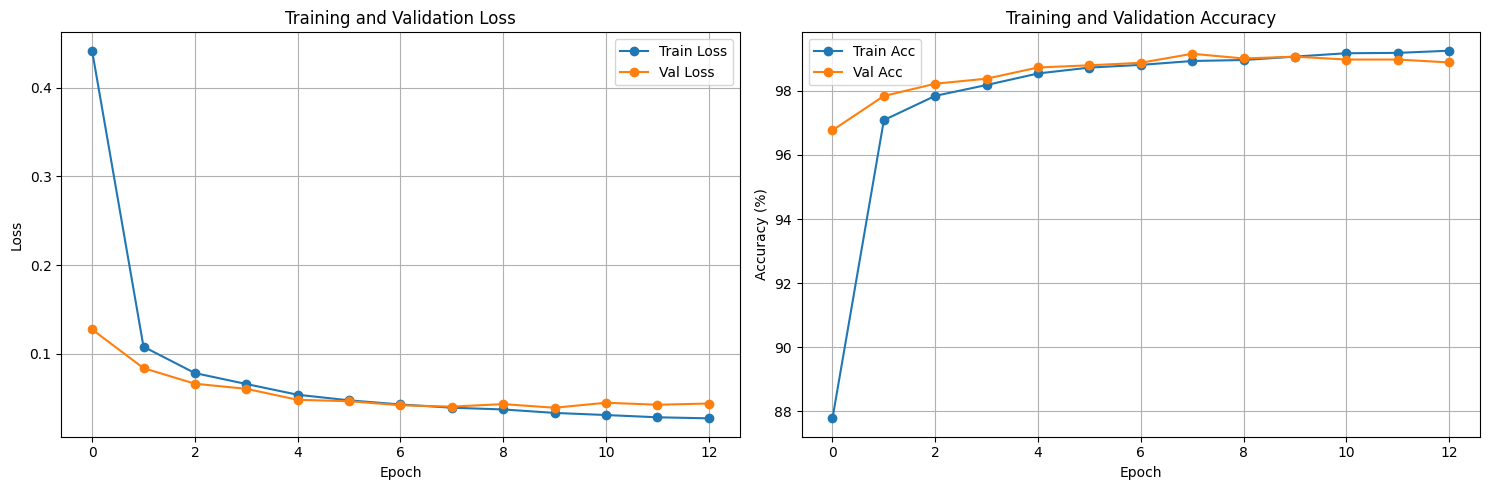

✓ Training curves saved as 'training_curves.png'


In [17]:
# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Loss plot
ax1.plot(history['train_loss'], label='Train Loss', marker='o')
ax1.plot(history['val_loss'], label='Val Loss', marker='o')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss')
ax1.legend()
ax1.grid(True)

# Accuracy plot
ax2.plot(history['train_acc'], label='Train Acc', marker='o')
ax2.plot(history['val_acc'], label='Val Acc', marker='o')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training and Validation Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Training curves saved as 'training_curves.png'")

## 11. Training Summary

## 12. Save Class Names (Important!)

In [18]:
# Save class names to JSON
with open('class_names.json', 'w') as f:
    json.dump(class_names, f, indent=2)

print(f"✓ Class names saved to 'class_names.json'")
print(f"\nClass mapping:")
for i, name in enumerate(class_names):
    print(f"   {i}: {name}")

✓ Class names saved to 'class_names.json'

Class mapping:
   0: Accessories
   1: Apparel
   2: Footwear
   3: Free Items
   4: Home
   5: Personal Care
   6: Sporting Goods


## 13. Test Model on Sample Images

Sample predictions:


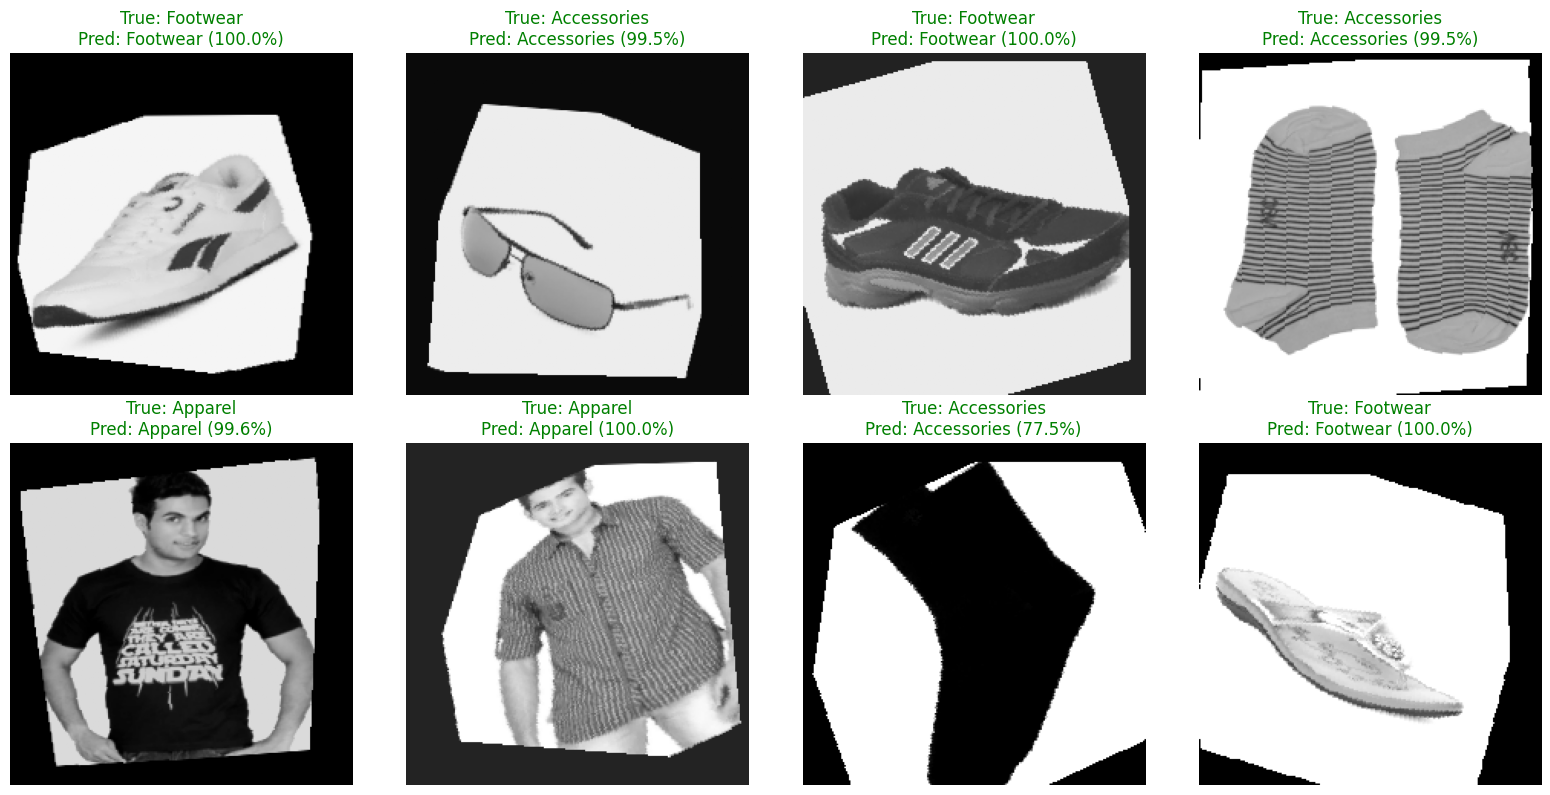

In [19]:
# Load best model
checkpoint = torch.load(SAVE_PATH)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

# Test on a few validation samples
def test_samples(model, dataloader, num_samples=8):
    images, labels = next(iter(dataloader))
    images = images.to(device)
    
    with torch.no_grad():
        outputs = model(images)
        probabilities = torch.nn.functional.softmax(outputs, dim=1)
        confidences, predictions = torch.max(probabilities, 1)
    
    # Visualize
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.ravel()
    
    for i in range(min(num_samples, len(images))):
        img = images[i].cpu().permute(1, 2, 0).numpy()
        true_label = class_names[labels[i]]
        pred_label = class_names[predictions[i]]
        conf = confidences[i].item() * 100
        
        axes[i].imshow(img)
        color = 'green' if predictions[i] == labels[i] else 'red'
        axes[i].set_title(f"True: {true_label}\nPred: {pred_label} ({conf:.1f}%)", color=color)
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

print("Sample predictions:")
test_samples(model, val_loader)

In [20]:
print("\n" + "="*60)
print("✅ TRAINING COMPLETE!")
print("="*60)
print("\n📥 Download these files:")
print(f"   1. {SAVE_PATH}")
print(f"   2. class_names.json")
print(f"   3. training_curves.png (optional)")
print("\n🔄 To use in your app:")
print("   1. Replace 'models/clothing_classifier.pth' with the new file")
print("   2. Copy 'class_names.json' to your project (optional)")
print("   3. Run your app.py - confidence should be MUCH higher now!")
print("\n💡 Expected improvements:")
print("   - Confidence scores: 70-95% (was 11-45%)")
print("   - Better multi-angle recognition")
print("   - More accurate classifications")
print("="*60)


✅ TRAINING COMPLETE!

📥 Download these files:
   1. improved_clothing_classifier.pth
   2. class_names.json
   3. training_curves.png (optional)

🔄 To use in your app:
   1. Replace 'models/clothing_classifier.pth' with the new file
   2. Copy 'class_names.json' to your project (optional)
   3. Run your app.py - confidence should be MUCH higher now!

💡 Expected improvements:
   - Confidence scores: 70-95% (was 11-45%)
   - Better multi-angle recognition
   - More accurate classifications


## 14. Download Files

**Download these 2 files:**
1. `improved_clothing_classifier.pth` - The trained model
2. `class_names.json` - Class names mapping

**Then replace in your project:**
- Replace `models/clothing_classifier.pth` with the new .pth file
- Update class names in your code if needed